In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o dataset
# Ajuste o nome do arquivo se necessário
df = pd.read_csv('/content/desafio_nps_fase_1.csv')

# Verificar as primeiras linhas e informações básicas
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [3]:
# 1. Checar valores nulos
print(df.isnull().sum())

# 2. Tratamento de Nulos
# Exemplo: se o NPS estiver vazio, o cliente não respondeu, então não podemos usar esse dado
# A decisão depende da sua estratégia, mas geralmente removemos nulos da target
df = df.dropna(subset=['nps_score'])

# 3. Tratamento de colunas operacionais
# Se houver valores nulos em 'delivery_delay_days', talvez signifique que não houve atraso (preencher com 0)
df['delivery_delay_days'] = df['delivery_delay_days'].fillna(0)

# 4. Converter colunas para o tipo correto (se necessário)
# Garantir que datas ou indicadores numéricos estejam como numéricos
df['order_value'] = pd.to_numeric(df['order_value'], errors='coerce')

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64


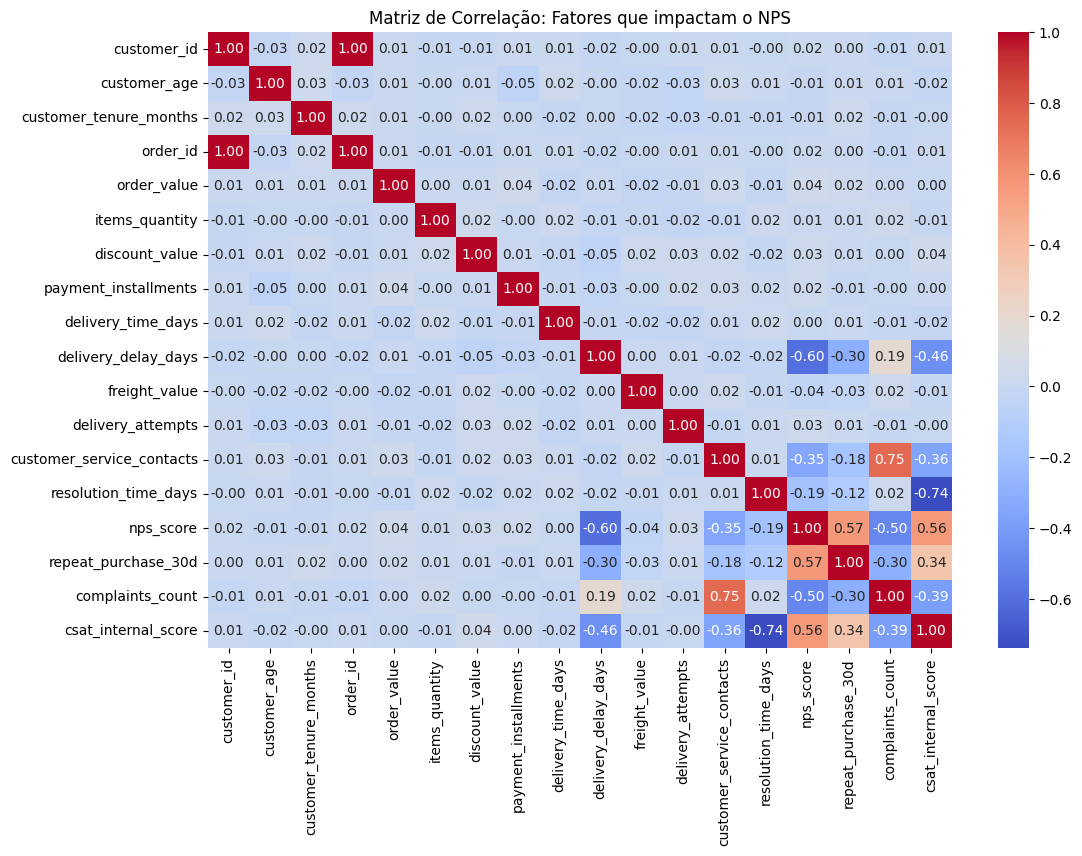

In [4]:
# Calcular a matriz de correlação
# Selecionamos apenas colunas numéricas para a correlação
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Criar o mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação: Fatores que impactam o NPS")
plt.show()

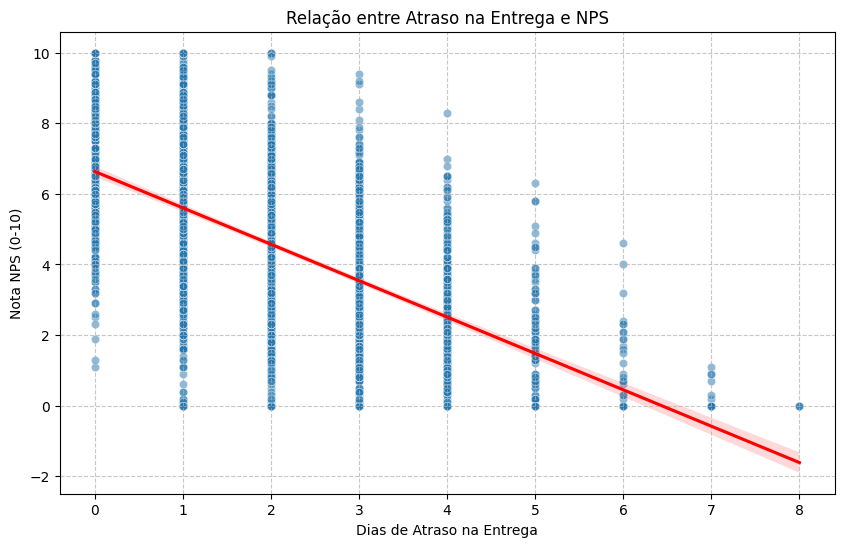

In [5]:
# Criar o gráfico de dispersão para visualizar o ponto de ruptura
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='delivery_delay_days', y='nps_score', alpha=0.5)

# Adicionar uma linha de tendência para facilitar a leitura
sns.regplot(data=df, x='delivery_delay_days', y='nps_score', scatter=False, color='red')

plt.title("Relação entre Atraso na Entrega e NPS")
plt.xlabel("Dias de Atraso na Entrega")
plt.ylabel("Nota NPS (0-10)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()